In [112]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


# Dagshub/Mlflow Initialization

In [113]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

Note: you may need to restart the kernel to use updated packages.


In [114]:
import dagshub
import mlflow
import mlflow.sklearn

dagshub.init(repo_owner='Nestor-Dzadzamia', repo_name='ML-Advanced-Regression-Techniques', mlflow=True)
PATH = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv'

Initialized MLflow to track repo "Nestor-Dzadzamia/ML-Advanced-Regression-Techniques"

Repository Nestor-Dzadzamia/ML-Advanced-Regression-Techniques initialized!

# EDA - Exploratory Data Analysis

In [115]:
df = pd.read_csv(PATH)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [116]:
df.shape

(1460, 81)

# Train/Test Split

In [117]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SalePrice', 'Id'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
X_train.shape, X_test.shape

((1168, 79), (292, 79))

In [119]:
X_train.isnull().sum()

MSSubClass         0
MSZoning           0
LotFrontage      217
LotArea            0
Street             0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
Length: 79, dtype: int64

In [120]:
X_train.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1168.000000,951.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1162.000000,1168.000000,1168.000000,...,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000
mean,56.849315,70.343849,10689.642123,6.121575,5.584760,1970.965753,1984.897260,103.771945,446.023973,45.152397,...,476.273973,95.946918,49.578767,21.839041,3.812500,15.407534,2.955479,51.267123,6.356164,2007.818493
std,42.531862,24.897021,10759.366198,1.367619,1.116062,30.675495,20.733955,173.032238,459.070977,158.217499,...,211.095373,129.685939,69.433580,62.083227,31.519664,55.881148,41.648504,553.039684,2.670707,1.322639
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,59.000000,7587.250000,5.000000,5.000000,1953.000000,1966.000000,0.000000,0.000000,0.000000,...,341.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,50.000000,70.000000,9600.000000,6.000000,5.000000,1972.000000,1994.000000,0.000000,384.500000,0.000000,...,482.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,80.000000,11700.000000,7.000000,6.000000,2001.000000,2004.000000,166.000000,721.000000,0.000000,...,576.000000,168.000000,74.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1378.000000,5644.000000,1127.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [121]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1168 non-null   int64  
 1   MSZoning       1168 non-null   object 
 2   LotFrontage    951 non-null    float64
 3   LotArea        1168 non-null   int64  
 4   Street         1168 non-null   object 
 5   Alley          74 non-null     object 
 6   LotShape       1168 non-null   object 
 7   LandContour    1168 non-null   object 
 8   Utilities      1168 non-null   object 
 9   LotConfig      1168 non-null   object 
 10  LandSlope      1168 non-null   object 
 11  Neighborhood   1168 non-null   object 
 12  Condition1     1168 non-null   object 
 13  Condition2     1168 non-null   object 
 14  BldgType       1168 non-null   object 
 15  HouseStyle     1168 non-null   object 
 16  OverallQual    1168 non-null   int64  
 17  OverallCond    1168 non-null   int64  
 18  YearBuilt  

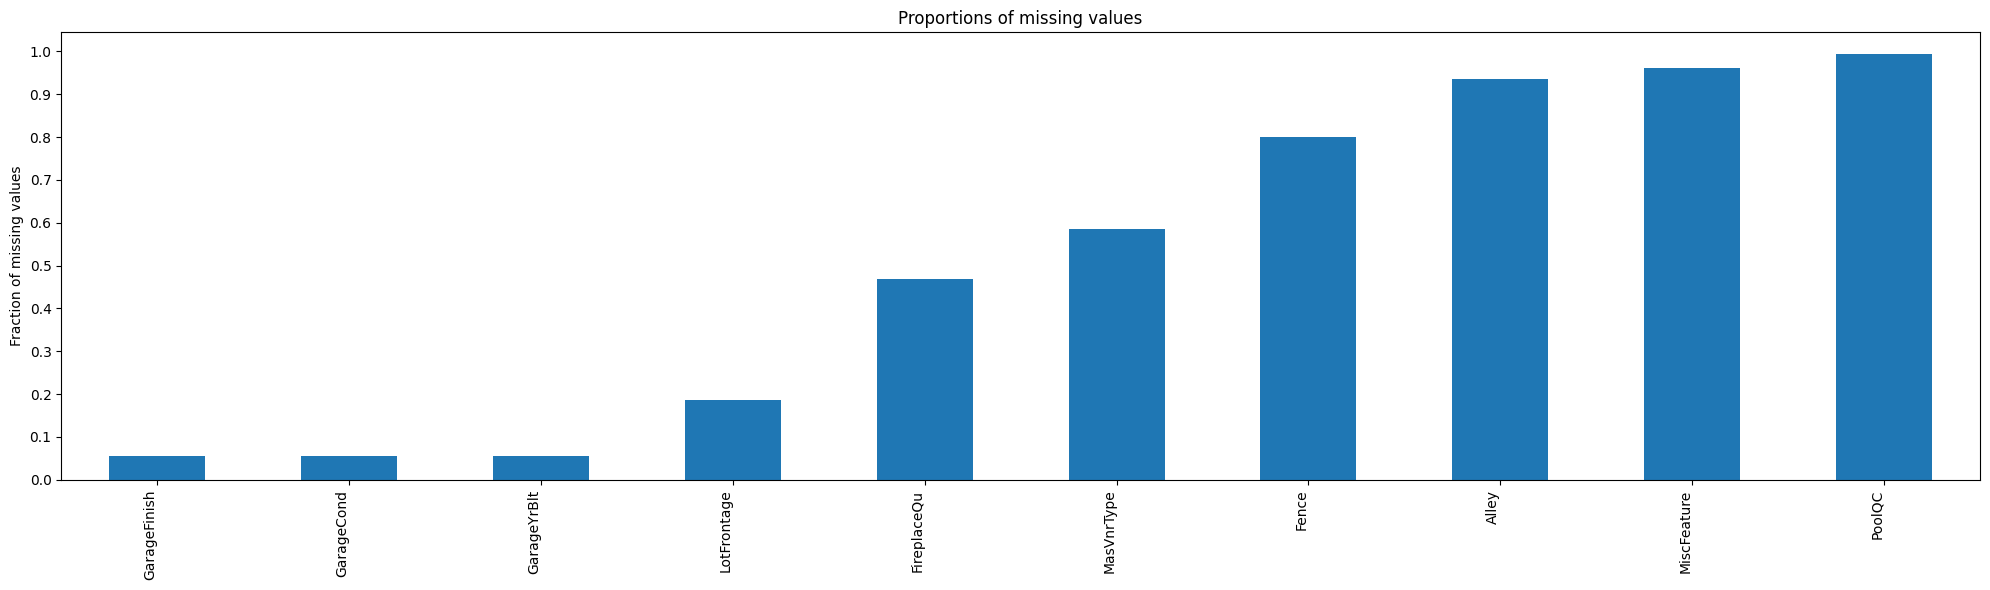

In [122]:
import matplotlib.pyplot as plt

null_ratio = X_train.isna().sum() / X_train.shape[0]
null_ratio = null_ratio[null_ratio > 0].sort_values(ascending=True).tail(10)

plt.figure(figsize=(20, 6))
plt.yticks(np.arange(0, 1.1 , 0.1))
plt.xticks(rotation=45, ha='right')
null_ratio.plot(kind='bar')
plt.title('Proportions of missing values')
plt.ylabel('Fraction of missing values')
plt.tight_layout()
plt.show()

In [123]:
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
X_train.drop(columns=cols_to_drop, inplace=True)

In [124]:
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

In [125]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

In [126]:
print(f"{len(cat_cols)} : {cat_cols}")

39 : ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


In [127]:
print(f"{len(num_cols)} : {num_cols}")

36 : ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [128]:
for col in cat_cols:
    print(X_train[col].value_counts())

MSZoning
RL         924
RM         172
FV          53
RH          15
C (all)      4
Name: count, dtype: int64
Street
Pave    1164
Grvl       4
Name: count, dtype: int64
LotShape
Reg    729
IR1    394
IR2     37
IR3      8
Name: count, dtype: int64
LandContour
Lvl    1059
Bnk      48
HLS      35
Low      26
Name: count, dtype: int64
Utilities
AllPub    1167
NoSeWa       1
Name: count, dtype: int64
LotConfig
Inside     822
Corner     221
CulDSac     84
FR2         38
FR3          3
Name: count, dtype: int64
LandSlope
Gtl    1108
Mod      51
Sev       9
Name: count, dtype: int64
Neighborhood
NAmes      181
CollgCr    115
OldTown     91
Edwards     87
Somerst     69
NWAmes      66
Gilbert     65
NridgHt     61
Sawyer      58
BrkSide     45
Crawfor     44
SawyerW     44
Mitchel     40
NoRidge     33
Timber      28
IDOTRR      26
SWISU       21
StoneBr     20
ClearCr     19
Blmngtn     15
BrDale      13
MeadowV     10
Veenker      9
NPkVill      7
Blueste      1
Name: count, dtype: int64
Con

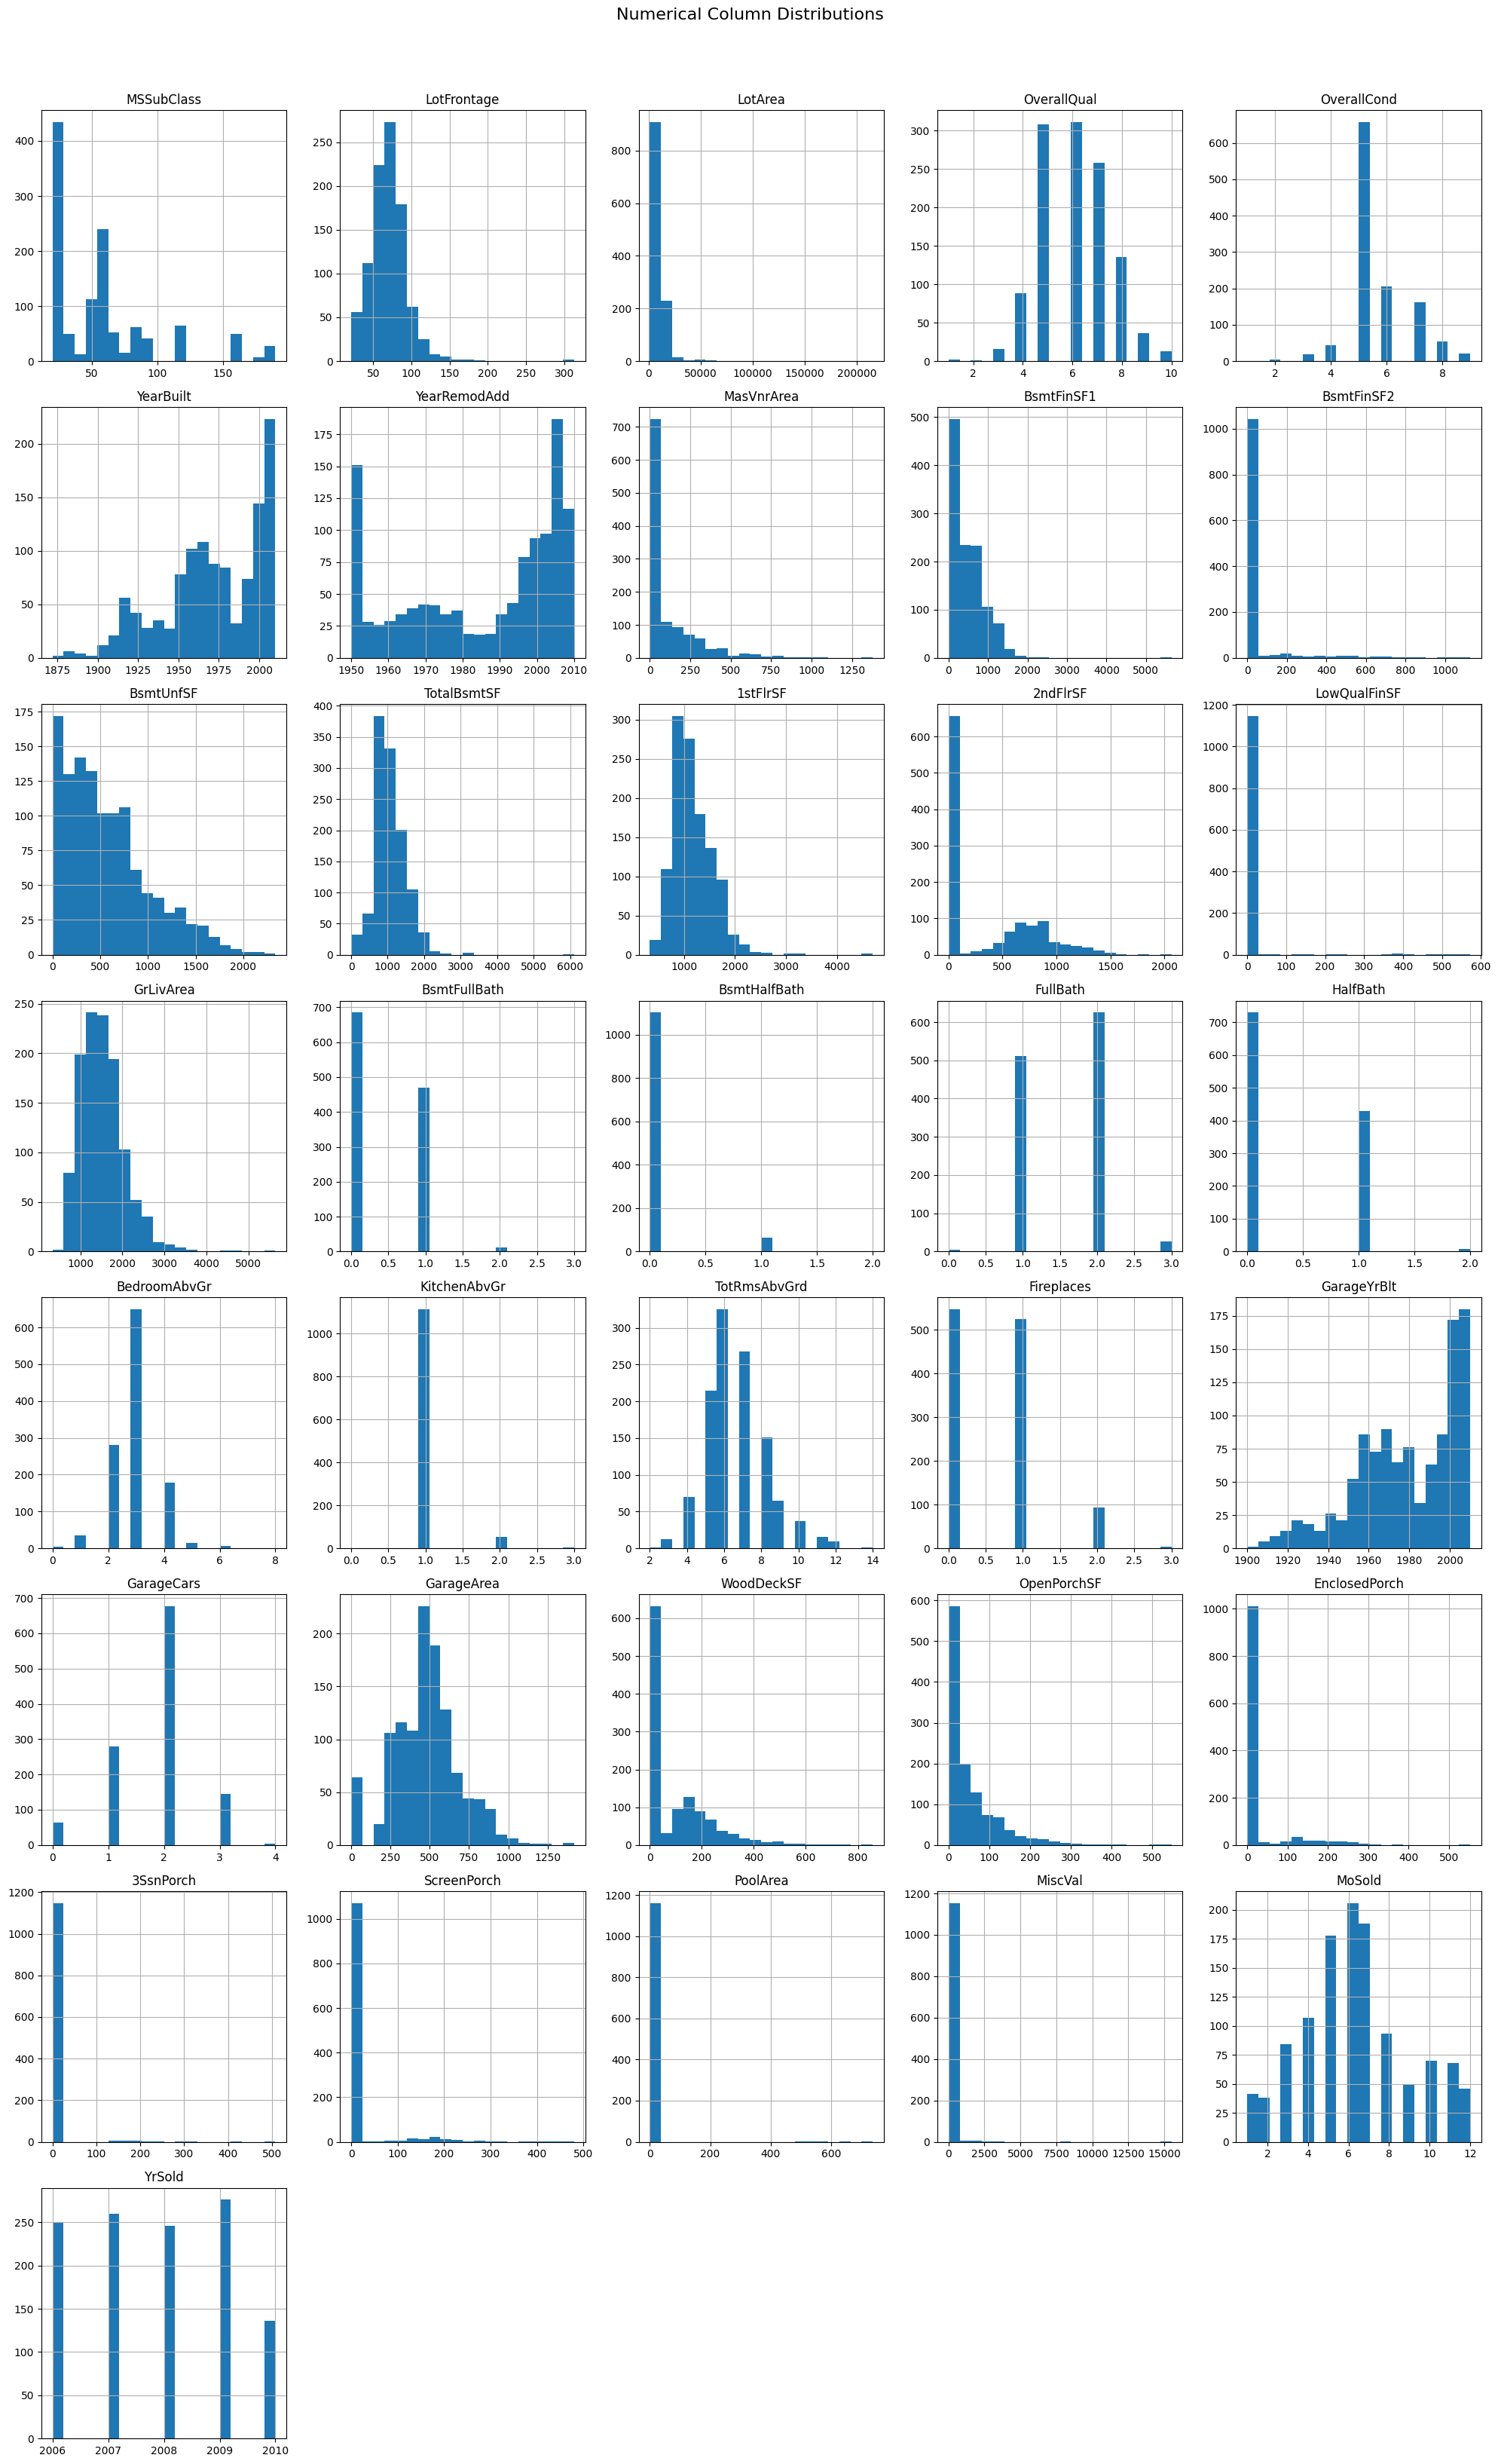

In [129]:
import math

cols_per_row = 5
rows = math.ceil(len(num_cols) / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    X_train[col].hist(bins=20, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Column Distributions', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [130]:
zero_dominant = [col for col in num_cols if (X_train[col] == 0).mean() > 0.95]

In [131]:
zero_dominant

['LowQualFinSF', '3SsnPorch', 'PoolArea', 'MiscVal']

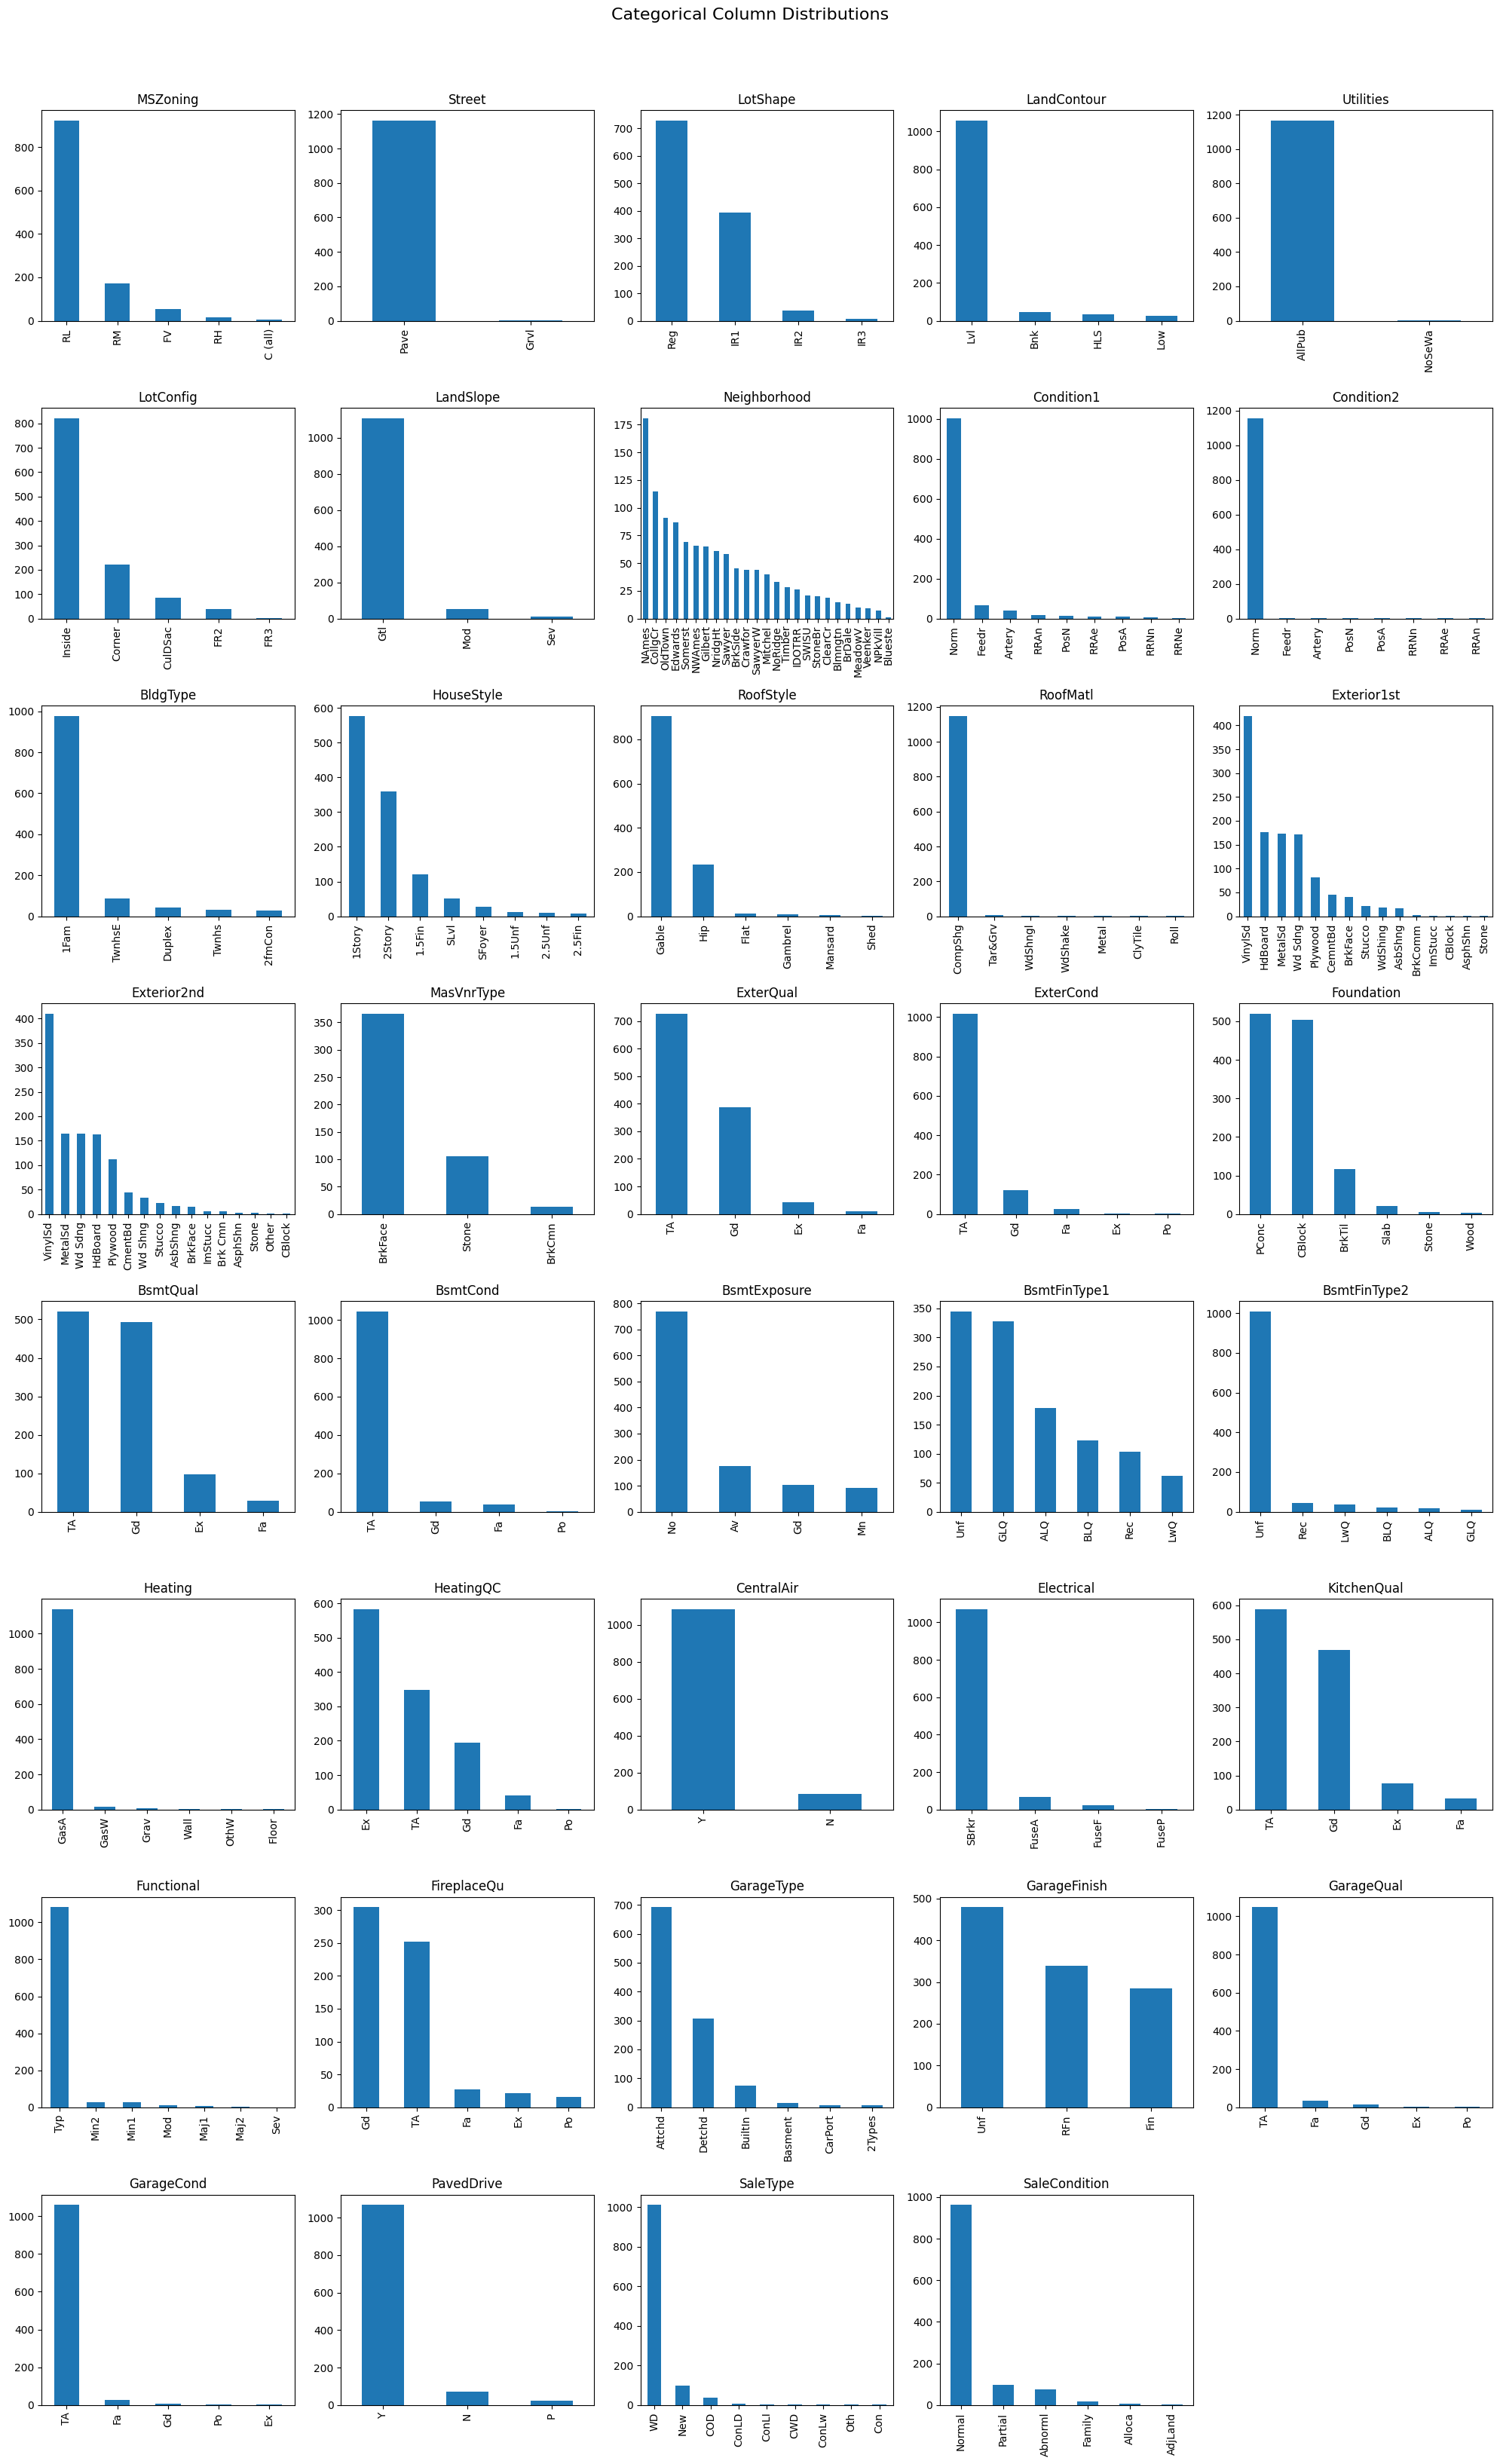

In [132]:
cols_per_row = 5
rows = math.ceil(len(cat_cols) / cols_per_row)
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    X_train[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Column Distributions', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [133]:
dominant_cats = [col for col in cat_cols if X_train[col].value_counts(normalize=True).iloc[0] > 0.95]

In [134]:
dominant_cats

['Street',
 'Utilities',
 'Condition2',
 'RoofMatl',
 'Heating',
 'GarageQual',
 'GarageCond']

# Data Cleaning

In [135]:
X_train.drop(columns=zero_dominant, inplace=True)
X_train.drop(columns=dominant_cats, inplace=True)

cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

In [136]:
X_test = X_test.drop(columns=zero_dominant, errors='ignore')
X_test = X_test.drop(columns=dominant_cats, errors='ignore')

In [137]:
train_medians = X_train[num_cols].median()

In [138]:
X_train[num_cols] = X_train[num_cols].fillna(train_medians)

In [139]:
X_test[num_cols] = X_test[num_cols].fillna(train_medians)

In [140]:
train_modes = {col: X_train[col].mode()[0] for col in cat_cols}

In [141]:
for col in cat_cols:
    X_train[col] = X_train[col].fillna(X_train[col].mode()[0])

In [142]:
for col in cat_cols:
    X_test[col] = X_test[col].fillna(X_train[col].mode()[0])

In [143]:
X_train.isnull().sum().sum()

np.int64(0)

# Feature Engineering

In [144]:
for col in cat_cols:
    print(col, X_train[col].nunique(), end=" ")


MSZoning 5 LotShape 4 LandContour 4 LotConfig 5 LandSlope 3 Neighborhood 25 Condition1 9 BldgType 5 HouseStyle 8 RoofStyle 6 Exterior1st 15 Exterior2nd 16 MasVnrType 3 ExterQual 4 ExterCond 5 Foundation 6 BsmtQual 4 BsmtCond 4 BsmtExposure 4 BsmtFinType1 6 BsmtFinType2 6 HeatingQC 5 CentralAir 2 Electrical 4 KitchenQual 4 Functional 7 FireplaceQu 5 GarageType 6 GarageFinish 3 PavedDrive 3 SaleType 9 SaleCondition 6 

In [145]:
s = X_train[cat_cols].nunique()

woe_columns = list(s[s > 3].index)
one_hot_columns = list(s[s <= 3].index)

In [146]:
woe_columns, one_hot_columns

(['MSZoning',
  'LotShape',
  'LandContour',
  'LotConfig',
  'Neighborhood',
  'Condition1',
  'BldgType',
  'HouseStyle',
  'RoofStyle',
  'Exterior1st',
  'Exterior2nd',
  'ExterQual',
  'ExterCond',
  'Foundation',
  'BsmtQual',
  'BsmtCond',
  'BsmtExposure',
  'BsmtFinType1',
  'BsmtFinType2',
  'HeatingQC',
  'Electrical',
  'KitchenQual',
  'Functional',
  'FireplaceQu',
  'GarageType',
  'SaleType',
  'SaleCondition'],
 ['LandSlope', 'MasVnrType', 'CentralAir', 'GarageFinish', 'PavedDrive'])

In [147]:
X_train['TotalSF'] = X_train['TotalBsmtSF'] + X_train['1stFlrSF'] + X_train['2ndFlrSF']
X_train['TotalBath'] = (X_train['FullBath'] + X_train['BsmtFullBath'] + 
                0.5 * X_train['HalfBath'] + 0.5 * X_train['BsmtHalfBath'])
X_train['HouseAge'] = X_train['YrSold'] - X_train['YearBuilt']
X_train['Remodeled'] = (X_train['YearRemodAdd'] != X_train['YearBuilt']).astype(int)

In [148]:
X_test['TotalSF'] = X_test['TotalBsmtSF'] + X_test['1stFlrSF'] + X_test['2ndFlrSF']
X_test['TotalBath'] = (X_test['FullBath'] + X_test['BsmtFullBath'] + 
                        0.5 * X_test['HalfBath'] + 0.5 * X_test['BsmtHalfBath'])
X_test['HouseAge'] = X_test['YrSold'] - X_test['YearBuilt']
X_test['Remodeled'] = (X_test['YearRemodAdd'] != X_test['YearBuilt']).astype(int)

In [149]:
X_test.shape, X_train.shape

((292, 68), (1168, 68))

In [150]:
X_train.tail()

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,EnclosedPorch,ScreenPorch,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalBath,HouseAge,Remodeled
1095,20,RL,78.0,9317,IR1,Lvl,Inside,Gtl,CollgCr,Norm,...,0,0,3,2007,WD,Normal,2628,2.0,1,0
1130,50,RL,65.0,7804,Reg,Lvl,Inside,Gtl,SWISU,Norm,...,0,0,12,2009,WD,Normal,3103,3.0,81,1
1294,20,RL,60.0,8172,Reg,Lvl,Inside,Gtl,Edwards,Norm,...,0,0,4,2006,WD,Normal,1728,2.0,51,1
860,50,RL,55.0,7642,Reg,Lvl,Corner,Gtl,Crawfor,Norm,...,0,0,6,2007,WD,Normal,2338,1.5,89,1
1126,120,RL,53.0,3684,Reg,Lvl,Inside,Gtl,Blmngtn,Norm,...,0,0,6,2009,WD,Normal,2928,2.0,2,0


In [151]:
target_means = {col: y_train.groupby(X_train[col]).mean() for col in woe_columns}

In [152]:
for col in woe_columns:
    means = y_train.groupby(X_train[col]).mean()
    X_train[col] = X_train[col].map(means)
    X_test[col] = X_test[col].map(means)

X_train = pd.get_dummies(X_train, columns=one_hot_columns, drop_first=True)
X_test = pd.get_dummies(X_test, columns=one_hot_columns, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [153]:
X_train.dtypes.value_counts()

int64      32
float64    31
bool        9
Name: count, dtype: int64

In [154]:
X_test.dtypes.value_counts()

int64      32
float64    31
bool        9
Name: count, dtype: int64

In [155]:
bool_cols = [col for col in X_train.columns if X_train[col].dtype == 'bool']
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [156]:
X_train.dtypes.value_counts()

int64      41
float64    31
Name: count, dtype: int64

In [157]:
X_test.dtypes.value_counts()

int64      41
float64    31
Name: count, dtype: int64

# Feature Selection

### Correlation filter

In [158]:
correlation_matrix = X_train.corr().abs()

upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

features_to_drop = set()
for col in upper.columns:
    if any(upper[col] > 0.85):
        partners = upper.index[upper[col] > 0.85].tolist()
        for partner in partners:
            if correlation_matrix[col].mean() >= correlation_matrix[partner].mean():
                features_to_drop.add(col)
            else:
                features_to_drop.add(partner)

X_train = X_train.drop(columns=features_to_drop)
X_test = X_test.drop(columns=features_to_drop)

In [159]:
X_train.shape[1]

66

In [160]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

rfe = RFE(estimator=LinearRegression(), n_features_to_select=20)
rfe.fit(X_train, y_train)

selected_cols = X_train.columns[rfe.support_].tolist()
X_train = X_train[selected_cols]
X_test = X_test[selected_cols]

In [161]:
X_train.shape[1], X_test.shape[1]

(20, 20)

# Linear Regression

In [162]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
import skops.io as sio

kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = [
    {"model": LinearRegression(), "name": "LinearRegression"},
    {"model": Ridge(alpha=0.1),   "name": "Ridge_a0.1"},
    {"model": Ridge(alpha=1.0),   "name": "Ridge_a1.0"},
    {"model": Ridge(alpha=10.0),  "name": "Ridge_a10.0"},
    {"model": Lasso(alpha=0.1),   "name": "Lasso_a0.1"},
    {"model": Lasso(alpha=1.0),   "name": "Lasso_a1.0"},
    {"model": Lasso(alpha=10.0),  "name": "Lasso_a10.0"},
]

mlflow.set_experiment("house_prices")

for params in param_grid:
    with mlflow.start_run(run_name=params["name"]):

        model = params["model"]

        cv_results = cross_validate(
            model, X_train, y_train,
            cv=kf,
            scoring=["r2", "neg_root_mean_squared_error"],
            return_train_score=True
        )

        mlflow.log_metric("train_r2",   cv_results["train_r2"].mean())
        mlflow.log_metric("train_rmse", -cv_results["train_neg_root_mean_squared_error"].mean())
        mlflow.log_metric("val_r2",     cv_results["test_r2"].mean())
        mlflow.log_metric("val_rmse",   -cv_results["test_neg_root_mean_squared_error"].mean())

        model.fit(X_train, y_train)
        test_preds = model.predict(X_test)

        mlflow.log_metric("test_r2",   r2_score(y_test, test_preds))
        mlflow.log_metric("test_rmse", root_mean_squared_error(y_test, test_preds))

        sio.dump(model, "model.skops")
        mlflow.log_artifact("model.skops")

        print(f"{params['name']} | val_r2={cv_results['test_r2'].mean():.4f} | test_r2={r2_score(y_test, test_preds):.4f}")

# Decision tree

In [163]:
from sklearn.tree import DecisionTreeRegressor

param_grid_dt = [
    {"max_depth": 3,    "min_samples_split": 2,  "min_samples_leaf": 1},
    {"max_depth": 3,    "min_samples_split": 5,  "min_samples_leaf": 2},
    {"max_depth": 3,    "min_samples_split": 10, "min_samples_leaf": 4},
    
    {"max_depth": 5,    "min_samples_split": 2,  "min_samples_leaf": 1},
    {"max_depth": 5,    "min_samples_split": 5,  "min_samples_leaf": 2},
    {"max_depth": 5,    "min_samples_split": 10, "min_samples_leaf": 4},
    
    {"max_depth": 10,   "min_samples_split": 2,  "min_samples_leaf": 1},
    {"max_depth": 10,   "min_samples_split": 5,  "min_samples_leaf": 2},
    {"max_depth": 10,   "min_samples_split": 10, "min_samples_leaf": 4},
    
    {"max_depth": None, "min_samples_split": 2,  "min_samples_leaf": 1},
    {"max_depth": None, "min_samples_split": 10, "min_samples_leaf": 5},
]


mlflow.set_experiment("decision_tree")

for params in param_grid_dt:
    run_name = f"DT_depth{params['max_depth']}_split{params['min_samples_split']}_leaf{params['min_samples_leaf']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_type", "DecisionTreeRegressor")
        mlflow.log_params(params)

        model = DecisionTreeRegressor(**params, random_state=42)

        cv_results = cross_validate(
            model, X_train, y_train,
            cv=kf,
            scoring=["r2", "neg_root_mean_squared_error"],
            return_train_score=True
        )

        mlflow.log_metric("train_r2",   cv_results["train_r2"].mean())
        mlflow.log_metric("train_rmse", -cv_results["train_neg_root_mean_squared_error"].mean())

        mlflow.log_metric("val_r2",     cv_results["test_r2"].mean())
        mlflow.log_metric("val_rmse",   -cv_results["test_neg_root_mean_squared_error"].mean())

        model.fit(X_train, y_train)
        test_preds = model.predict(X_test)

        mlflow.log_metric("test_r2",   r2_score(y_test, test_preds))
        mlflow.log_metric("test_rmse", root_mean_squared_error(y_test, test_preds))

        sio.dump(model, "model.skops")
        mlflow.log_artifact("model.skops")

        print(f"depth={params['max_depth']} split={params['min_samples_split']} "
              f"leaf={params['min_samples_leaf']} | "
              f"val_r2={cv_results['test_r2'].mean():.4f} | "
              f"test_r2={r2_score(y_test, test_preds):.4f}")


# Random Forest (Bagging - Bootstrap aggregating)

In [164]:
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = [
    {"n_estimators": 100, "max_depth": 5,    "min_samples_split": 2,  "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 5,    "min_samples_split": 5,  "min_samples_leaf": 2},
    {"n_estimators": 100, "max_depth": 10,   "min_samples_split": 2,  "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 10,   "min_samples_split": 5,  "min_samples_leaf": 2},
    {"n_estimators": 100, "max_depth": 10,   "min_samples_split": 10, "min_samples_leaf": 4},
    {"n_estimators": 100, "max_depth": None, "min_samples_split": 2,  "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": None, "min_samples_split": 10, "min_samples_leaf": 5},
    {"n_estimators": 200, "max_depth": 5,    "min_samples_split": 5,  "min_samples_leaf": 2},
    {"n_estimators": 200, "max_depth": 10,   "min_samples_split": 5,  "min_samples_leaf": 2},
    {"n_estimators": 200, "max_depth": None, "min_samples_split": 10, "min_samples_leaf": 4},
    {"n_estimators": 300, "max_depth": 10,   "min_samples_split": 5,  "min_samples_leaf": 2},
    {"n_estimators": 300, "max_depth": None, "min_samples_split": 10, "min_samples_leaf": 4},
]

mlflow.set_experiment("random_forest")

for params in param_grid_rf:
    run_name = f"RF_n{params['n_estimators']}_depth{params['max_depth']}_split{params['min_samples_split']}_leaf{params['min_samples_leaf']}"
    
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_type", "RandomForestRegressor")
        mlflow.log_params(params)

        model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)

        cv_results = cross_validate(
            model, X_train, y_train,
            cv=kf,
            scoring=['r2', 'neg_root_mean_squared_error'],
            return_train_score=True
        )

        mlflow.log_metric("train_r2",   cv_results["train_r2"].mean())
        mlflow.log_metric("train_rmse", -cv_results["train_neg_root_mean_squared_error"].mean())
        mlflow.log_metric("val_r2",     cv_results["test_r2"].mean())
        mlflow.log_metric("val_rmse",   -cv_results["test_neg_root_mean_squared_error"].mean())


        model.fit(X_train, y_train)
        test_preds = model.predict(X_test)

        mlflow.log_metric("test_r2",   r2_score(y_test, test_preds))
        mlflow.log_metric("test_rmse", root_mean_squared_error(y_test, test_preds))

        sio.dump(model, "model.skops")
        mlflow.log_artifact("model.skops")

        print(f"{run_name} | val_r2={cv_results['test_r2'].mean():.4f} | test_r2={r2_score(y_test, test_preds):.4f}")

# XGBoost

In [165]:
from xgboost import XGBRegressor

param_grid_xgb = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1,  "subsample": 0.8},
    {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.1,  "subsample": 0.8},
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.1,  "subsample": 0.8},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1,  "subsample": 0.8},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.9},
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.9},
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.01, "subsample": 0.9},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.01, "subsample": 0.9},
    {"n_estimators": 500, "max_depth": 3, "learning_rate": 0.01, "subsample": 0.9},
]

mlflow.set_experiment("xgboost")

for params in param_grid_xgb:
    run_name = f"XGB_n{params['n_estimators']}_depth{params['max_depth']}_lr{params['learning_rate']}_sub{params['subsample']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_type", "XGBRegressor")
        mlflow.log_params(params)

        model = XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)

        cv_results = cross_validate(
            model, X_train, y_train,
            cv=kf,
            scoring=["r2", "neg_root_mean_squared_error"],
            return_train_score=True
        )

        mlflow.log_metric("train_r2",   cv_results["train_r2"].mean())
        mlflow.log_metric("train_rmse", -cv_results["train_neg_root_mean_squared_error"].mean())
        mlflow.log_metric("val_r2",     cv_results["test_r2"].mean())
        mlflow.log_metric("val_rmse",   -cv_results["test_neg_root_mean_squared_error"].mean())

        model.fit(X_train, y_train)
        test_preds = model.predict(X_test)

        mlflow.log_metric("test_r2",   r2_score(y_test, test_preds))
        mlflow.log_metric("test_rmse", root_mean_squared_error(y_test, test_preds))

        sio.dump(model, "model.skops")
        mlflow.log_artifact("model.skops")

        print(f"{run_name} | val_r2={cv_results['test_r2'].mean():.4f} | test_r2={r2_score(y_test, test_preds):.4f}")

In [169]:
import pickle

inference_artifacts = {
    'zero_dominant': zero_dominant,
    'dominant_cats': dominant_cats,
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'woe_columns': woe_columns,
    'one_hot_columns': one_hot_columns,
    'selected_cols': selected_cols,
    'train_medians': train_medians,
    'train_modes': train_modes,
    'target_means': target_means,
    'train_columns': X_train.columns.tolist(),
}

with open("inference_artifacts.pkl", "wb") as f:
    pickle.dump(inference_artifacts, f)

print("artifacts saved")

with mlflow.start_run(run_name="inference_artifacts"):
    mlflow.log_artifact("inference_artifacts.pkl")
    artifacts_run_id = mlflow.active_run().info.run_id
    print(f"Artifacts run id: {artifacts_run_id}")

artifacts saved
Artifacts run id: e55c3858ebc0409d89d07aa6e6431c56
🏃 View run inference_artifacts at: https://dagshub.com/Nestor-Dzadzamia/ML-Advanced-Regression-Techniques.mlflow/#/experiments/0/runs/e55c3858ebc0409d89d07aa6e6431c56
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/ML-Advanced-Regression-Techniques.mlflow/#/experiments/0
